In [ ]:
!pip install -q transformers timm scikit-learn matplotlib seaborn

In [ ]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
from pathlib import Path

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset

from torchvision import datasets, transforms

from transformers import SwinModel
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# =========================================================
# CONFIGURATION
# =========================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", DEVICE)

# Change this path according to your Colab dataset location
DATASET_PATH = "/content/kvasir-v2"

# Training parameters
IMAGE_SIZE = 224
BATCH_SIZE = 8
EPOCHS = 10
LEARNING_RATE = 1e-4
NUM_WORKERS = 2

# Fusion parameters
FUSION_DIM = 256
NUM_HEADS = 8
NUM_FUSION_LAYERS = 2

print("Dataset:", DATASET_PATH)

Device: cuda
Dataset: /content/kvasir-v2


In [ ]:
import kagglehub

# Download latest version
DATASET_PATH = kagglehub.dataset_download("plhalvorsen/kvasir-v2-a-gastrointestinal-tract-dataset")

print("Path to dataset files:", DATASET_PATH)
# Example:
# DATASET_PATH = "/content/drive/MyDrive/Kvasir-v2"

100%|██████████| 2.32G/2.32G [00:27<00:00, 90.4MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/plhalvorsen/kvasir-v2-a-gastrointestinal-tract-dataset/versions/1


In [ ]:
dataset = datasets.ImageFolder(DATASET_PATH)

print("Total images:", len(dataset))
print("\nClasses:")

for i, cls in enumerate(dataset.classes):
    print(i, ":", cls)

Total images: 8000

Classes:
0 : dyed-lifted-polyps
1 : dyed-resection-margins
2 : esophagitis
3 : normal-cecum
4 : normal-pylorus
5 : normal-z-line
6 : polyps
7 : ulcerative-colitis


In [ ]:
train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(
        brightness=0.15,
        contrast=0.15,
        saturation=0.15
    ),
    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

test_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [ ]:
targets = np.array(dataset.targets)
indices = np.arange(len(dataset))

# 70% train, 15% validation, 15% test
train_idx, temp_idx = train_test_split(
    indices,
    test_size=0.30,
    stratify=targets,
    random_state=SEED
)

val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.50,
    stratify=targets[temp_idx],
    random_state=SEED
)

print("Training:", len(train_idx))
print("Validation:", len(val_idx))
print("Testing:", len(test_idx))

Training: 5600
Validation: 1200
Testing: 1200


In [ ]:
class KvasirDataset(Dataset):

    def __init__(self, root, indices, transform=None):
        self.dataset = datasets.ImageFolder(root)
        self.indices = indices
        self.transform = transform

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):

        real_idx = self.indices[idx]

        image, label = self.dataset[real_idx]

        if self.transform:
            image = self.transform(image)

        return image, label


train_dataset = KvasirDataset(
    DATASET_PATH,
    train_idx,
    train_transform
)

val_dataset = KvasirDataset(
    DATASET_PATH,
    val_idx,
    test_transform
)

test_dataset = KvasirDataset(
    DATASET_PATH,
    test_idx,
    test_transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

In [ ]:
print("Loading DINOv2...")

dino = torch.hub.load(
    'facebookresearch/dinov2',
    'dinov2_vits14'
)

dino = dino.to(DEVICE)
dino.eval()

# Freeze DINOv2
for param in dino.parameters():
    param.requires_grad = False

print("DINOv2 loaded.")

Loading DINOv2...
Downloading: "https://github.com/facebookresearch/dinov2/zipball/main" to /root/.cache/torch/hub/main.zip


/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


Downloading: "https://dl.fbaipublicfiles.com/dinov2/dinov2_vits14/dinov2_vits14_pretrain.pth" to /root/.cache/torch/hub/checkpoints/dinov2_vits14_pretrain.pth


100%|██████████| 84.2M/84.2M [00:00<00:00, 245MB/s]


DINOv2 loaded.


DINOv2-S/14 produces patch-level visual representations with 384 dimensions.

In [ ]:
print("Loading Swin Transformer...")

swin = SwinModel.from_pretrained(
    "microsoft/swin-tiny-patch4-window7-224"
)

swin = swin.to(DEVICE)
swin.eval()

# Freeze Swin
for param in swin.parameters():
    param.requires_grad = False

print("Swin Transformer loaded.")

Loading Swin Transformer...


config.json:   0%|          | 0.00/71.8k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  113MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/219 [00:00<?, ?it/s]

[transformers] SwinModel LOAD REPORT from: microsoft/swin-tiny-patch4-window7-224
Key               | Status     |  | 
------------------+------------+--+-
classifier.weight | UNEXPECTED |  | 
classifier.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Swin Transformer loaded.


Swin-Tiny produces final-stage spatial tokens with 768 dimensions.

In [ ]:
sample_images, sample_labels = next(iter(train_loader))

sample_images = sample_images.to(DEVICE)

with torch.no_grad():

    # DINOv2 patch tokens
    dino_features = dino.forward_features(sample_images)

    if isinstance(dino_features, dict):
        dino_patches = dino_features["x_norm_patchtokens"]
    else:
        dino_patches = dino_features

    # Swin patch tokens
    swin_output = swin(
        pixel_values=sample_images
    )

    swin_patches = swin_output.last_hidden_state

print("DINOv2 patch features:",
      dino_patches.shape)

print("Swin patch features:",
      swin_patches.shape)

DINOv2 patch features: torch.Size([8, 256, 384])
Swin patch features: torch.Size([8, 49, 768])


In [ ]:
class DINOv2SwinFusion(nn.Module):

    def __init__(
        self,
        dino_dim=384,
        swin_dim=768,
        fusion_dim=256,
        num_classes=8,
        num_heads=8,
        num_layers=2
    ):

        super().__init__()

        # ============================================
        # FEATURE ALIGNMENT
        # ============================================

        self.dino_projection = nn.Linear(
            dino_dim,
            fusion_dim
        )

        self.swin_projection = nn.Linear(
            swin_dim,
            fusion_dim
        )

        # ============================================
        # BRANCH EMBEDDINGS
        # ============================================

        self.dino_embedding = nn.Parameter(
            torch.randn(1, 1, fusion_dim)
        )

        self.swin_embedding = nn.Parameter(
            torch.randn(1, 1, fusion_dim)
        )

        # ============================================
        # FUSION TRANSFORMER
        # ============================================

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=fusion_dim,
            nhead=num_heads,
            dim_feedforward=fusion_dim * 4,
            dropout=0.1,
            activation="gelu",
            batch_first=True,
            norm_first=True
        )

        self.fusion_transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers
        )

        # ============================================
        # GATED FUSION
        # ============================================

        self.gate = nn.Sequential(
            nn.Linear(fusion_dim * 2, fusion_dim),
            nn.GELU(),
            nn.Linear(fusion_dim, fusion_dim),
            nn.Sigmoid()
        )

        # ============================================
        # CLASSIFICATION HEAD
        # ============================================

        self.classifier = nn.Sequential(
            nn.LayerNorm(fusion_dim),
            nn.Linear(fusion_dim, 128),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(
        self,
        dino_features,
        swin_features
    ):

        # --------------------------------------------
        # Project features to common dimension
        # --------------------------------------------

        dino_tokens = self.dino_projection(
            dino_features
        )

        swin_tokens = self.swin_projection(
            swin_features
        )

        # --------------------------------------------
        # Add branch identity
        # --------------------------------------------

        dino_tokens = (
            dino_tokens +
            self.dino_embedding
        )

        swin_tokens = (
            swin_tokens +
            self.swin_embedding
        )

        # --------------------------------------------
        # Token fusion
        # --------------------------------------------

        fused_tokens = torch.cat(
            [
                dino_tokens,
                swin_tokens
            ],
            dim=1
        )

        # --------------------------------------------
        # Fusion Transformer
        # --------------------------------------------

        transformed = self.fusion_transformer(
            fused_tokens
        )

        # --------------------------------------------
        # Separate DINO and Swin representations
        # --------------------------------------------

        dino_length = dino_tokens.shape[1]

        dino_output = transformed[
            :, :dino_length, :
        ]

        swin_output = transformed[
            :, dino_length:, :
        ]

        # --------------------------------------------
        # Global pooling
        # --------------------------------------------

        dino_global = dino_output.mean(
            dim=1
        )

        swin_global = swin_output.mean(
            dim=1
        )

        # --------------------------------------------
        # Learnable gated fusion
        # --------------------------------------------

        combined = torch.cat(
            [
                dino_global,
                swin_global
            ],
            dim=1
        )

        gate = self.gate(combined)

        fused_feature = (
            gate * dino_global +
            (1 - gate) * swin_global
        )

        # --------------------------------------------
        # Classification
        # --------------------------------------------

        logits = self.classifier(
            fused_feature
        )

        return logits

In [ ]:
NUM_CLASSES = len(dataset.classes)

model = DINOv2SwinFusion(
    dino_dim=384,
    swin_dim=768,
    fusion_dim=FUSION_DIM,
    num_classes=NUM_CLASSES,
    num_heads=NUM_HEADS,
    num_layers=NUM_FUSION_LAYERS
).to(DEVICE)

print(model)

DINOv2SwinFusion(
  (dino_projection): Linear(in_features=384, out_features=256, bias=True)
  (swin_projection): Linear(in_features=768, out_features=256, bias=True)
  (fusion_transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=True)
        )
        (linear1): Linear(in_features=256, out_features=1024, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=1024, out_features=256, bias=True)
        (norm1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (gate): Sequential(
    (0): Linear(in_features=512, out_features=256, bias=True)
    (1): GELU(approximate='none'

/tmp/ipykernel_1699/3100150230.py:55: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.fusion_transformer = nn.TransformerEncoder(


In [ ]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=EPOCHS
)

In [ ]:
def extract_features(images):

    with torch.no_grad():

        # ===============================
        # DINOv2
        # ===============================

        dino_output = dino.forward_features(
            images
        )

        if isinstance(dino_output, dict):

            dino_features = dino_output[
                "x_norm_patchtokens"
            ]

        else:

            dino_features = dino_output

        # ===============================
        # Swin
        # ===============================

        swin_output = swin(
            pixel_values=images
        )

        swin_features = (
            swin_output.last_hidden_state
        )

    return dino_features, swin_features

In [ ]:
def train_one_epoch():

    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(
            DEVICE,
            non_blocking=True
        )

        labels = labels.to(
            DEVICE,
            non_blocking=True
        )

        # Extract frozen backbone features
        dino_features, swin_features = \
            extract_features(images)

        # Fusion model
        logits = model(
            dino_features,
            swin_features
        )

        loss = criterion(
            logits,
            labels
        )

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        running_loss += (
            loss.item() * labels.size(0)
        )

        predictions = torch.argmax(
            logits,
            dim=1
        )

        correct += (
            predictions == labels
        ).sum().item()

        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy

In [ ]:
def validate():

    model.eval()

    running_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(DEVICE)
            labels = labels.to(DEVICE)

            dino_features, swin_features = \
                extract_features(images)

            logits = model(
                dino_features,
                swin_features
            )

            loss = criterion(
                logits,
                labels
            )

            running_loss += (
                loss.item() *
                labels.size(0)
            )

            predictions = torch.argmax(
                logits,
                dim=1
            )

            correct += (
                predictions == labels
            ).sum().item()

            total += labels.size(0)

    loss = running_loss / total
    accuracy = correct / total

    return loss, accuracy

In [ ]:
train_losses = []
train_accuracies = []

val_losses = []
val_accuracies = []

best_val_accuracy = 0

for epoch in range(EPOCHS):

    train_loss, train_acc = \
        train_one_epoch()

    val_loss, val_acc = \
        validate()

    scheduler.step()

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)

    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] "
        f"Train Loss: {train_loss:.4f} "
        f"Train Acc: {train_acc*100:.2f}% "
        f"Val Loss: {val_loss:.4f} "
        f"Val Acc: {val_acc*100:.2f}%"
    )

    if val_acc > best_val_accuracy:

        best_val_accuracy = val_acc

        torch.save(
            model.state_dict(),
            "/content/best_dinov2_swin_fusion.pth"
        )

        print("Best model saved.")

Epoch [1/10] Train Loss: 0.5539 Train Acc: 80.12% Val Loss: 0.2768 Val Acc: 89.75%
Best model saved.
Epoch [2/10] Train Loss: 0.2367 Train Acc: 90.84% Val Loss: 0.2273 Val Acc: 91.58%
Best model saved.
Epoch [3/10] Train Loss: 0.1924 Train Acc: 92.55% Val Loss: 0.2626 Val Acc: 90.25%
Epoch [4/10] Train Loss: 0.1551 Train Acc: 94.16% Val Loss: 0.2241 Val Acc: 92.50%
Best model saved.
Epoch [5/10] Train Loss: 0.1388 Train Acc: 94.88% Val Loss: 0.2555 Val Acc: 91.42%
Epoch [6/10] Train Loss: 0.1203 Train Acc: 95.73% Val Loss: 0.2200 Val Acc: 93.00%
Best model saved.
Epoch [7/10] Train Loss: 0.1036 Train Acc: 95.96% Val Loss: 0.2189 Val Acc: 93.17%
Best model saved.
Epoch [8/10] Train Loss: 0.0926 Train Acc: 96.52% Val Loss: 0.2514 Val Acc: 92.08%
Epoch [9/10] Train Loss: 0.0826 Train Acc: 96.89% Val Loss: 0.2275 Val Acc: 92.83%
Epoch [10/10] Train Loss: 0.0764 Train Acc: 97.21% Val Loss: 0.2270 Val Acc: 92.92%


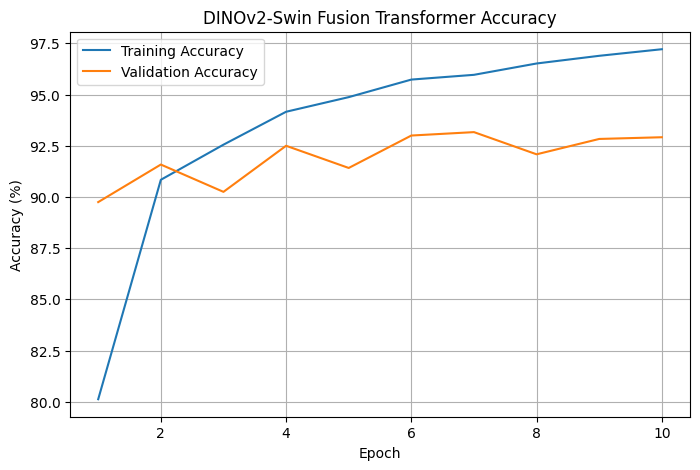

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1, EPOCHS+1),
    np.array(train_accuracies) * 100,
    label="Training Accuracy"
)

plt.plot(
    range(1, EPOCHS+1),
    np.array(val_accuracies) * 100,
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("DINOv2-Swin Fusion Transformer Accuracy")
plt.legend()
plt.grid(True)
plt.show()

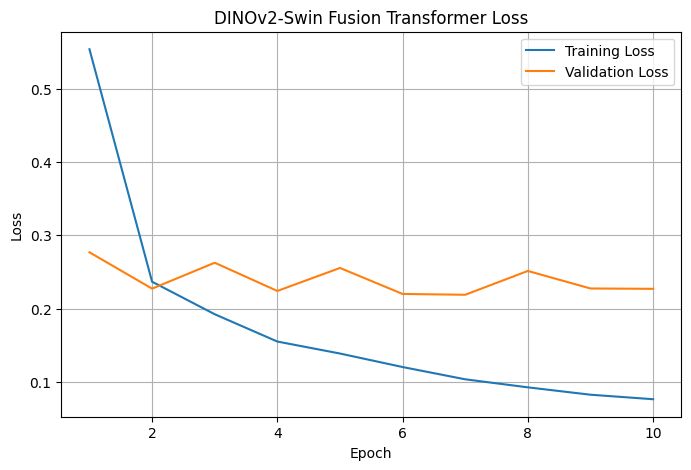

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1, EPOCHS+1),
    train_losses,
    label="Training Loss"
)

plt.plot(
    range(1, EPOCHS+1),
    val_losses,
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("DINOv2-Swin Fusion Transformer Loss")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
model.load_state_dict(
    torch.load(
        "/content/best_dinov2_swin_fusion.pth",
        map_location=DEVICE
    )
)

model.eval()

print("Best Fusion Transformer loaded.")

Best Fusion Transformer loaded.


In [ ]:
all_predictions = []
all_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(DEVICE)

        dino_features, swin_features = \
            extract_features(images)

        logits = model(
            dino_features,
            swin_features
        )

        predictions = torch.argmax(
            logits,
            dim=1
        )

        all_predictions.extend(
            predictions.cpu().numpy()
        )

        all_labels.extend(
            labels.numpy()
        )

all_predictions = np.array(
    all_predictions
)

all_labels = np.array(
    all_labels
)

In [ ]:
accuracy = accuracy_score(
    all_labels,
    all_predictions
)

precision = precision_score(
    all_labels,
    all_predictions,
    average="weighted",
    zero_division=0
)

recall = recall_score(
    all_labels,
    all_predictions,
    average="weighted",
    zero_division=0
)

f1 = f1_score(
    all_labels,
    all_predictions,
    average="weighted",
    zero_division=0
)

print("=" * 50)

print(
    f"Test Accuracy  : {accuracy*100:.2f}%"
)

print(
    f"Test Precision : {precision*100:.2f}%"
)

print(
    f"Test Recall    : {recall*100:.2f}%"
)

print(
    f"Test F1-Score  : {f1*100:.2f}%"
)

print("=" * 50)

Test Accuracy  : 92.67%
Test Precision : 92.70%
Test Recall    : 92.67%
Test F1-Score  : 92.67%


In [ ]:
print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=dataset.classes,
        digits=4,
        zero_division=0
    )
)

                        precision    recall  f1-score   support

    dyed-lifted-polyps     0.9448    0.9133    0.9288       150
dyed-resection-margins     0.9290    0.9600    0.9443       150
           esophagitis     0.8630    0.8400    0.8514       150
          normal-cecum     0.9477    0.9667    0.9571       150
        normal-pylorus     1.0000    0.9800    0.9899       150
         normal-z-line     0.8387    0.8667    0.8525       150
                polyps     0.9333    0.9333    0.9333       150
    ulcerative-colitis     0.9597    0.9533    0.9565       150

              accuracy                         0.9267      1200
             macro avg     0.9270    0.9267    0.9267      1200
          weighted avg     0.9270    0.9267    0.9267      1200



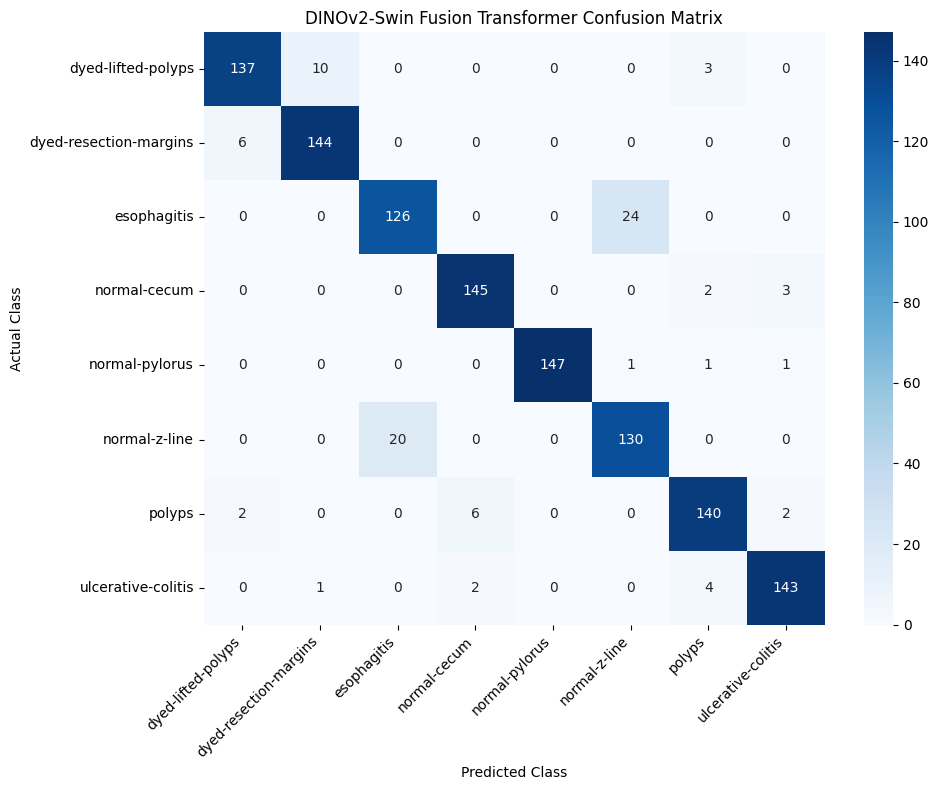

In [ ]:
cm = confusion_matrix(
    all_labels,
    all_predictions
)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=dataset.classes,
    yticklabels=dataset.classes
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.title(
    "DINOv2-Swin Fusion Transformer Confusion Matrix"
)

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()

plt.show()

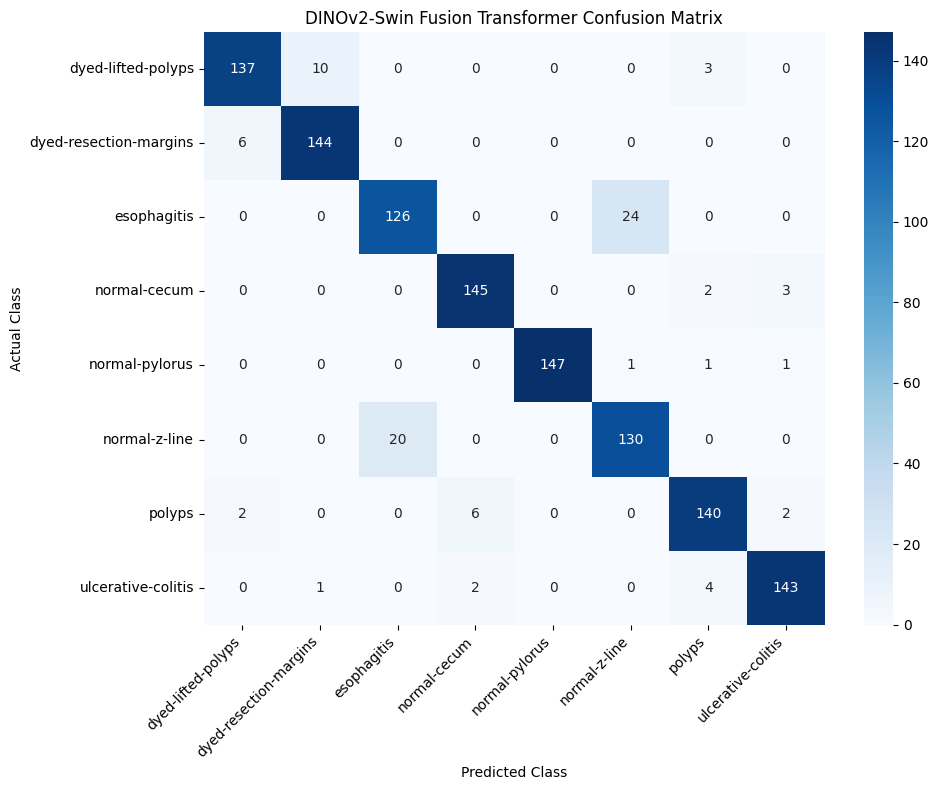

In [ ]:
cm = confusion_matrix(
    all_labels,
    all_predictions
)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=dataset.classes,
    yticklabels=dataset.classes
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.title(
    "DINOv2-Swin Fusion Transformer Confusion Matrix"
)

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()

plt.show()

In [ ]:
import json

config = {
    "architecture": "DINOv2-Swin Fusion Transformer",
    "dino_model": "dinov2_vits14",
    "swin_model": "microsoft/swin-tiny-patch4-window7-224",
    "fusion_dimension": FUSION_DIM,
    "num_heads": NUM_HEADS,
    "fusion_layers": NUM_FUSION_LAYERS,
    "num_classes": NUM_CLASSES,
    "classes": dataset.classes,
    "image_size": IMAGE_SIZE,
    "best_validation_accuracy": float(best_val_accuracy),
    "test_accuracy": float(accuracy),
    "test_precision": float(precision),
    "test_recall": float(recall),
    "test_f1": float(f1)
}

with open(
    "/content/fusion_model_config.json",
    "w"
) as f:

    json.dump(
        config,
        f,
        indent=4
    )

print("Configuration saved.")

Configuration saved.


In [ ]:
from google.colab import files

files.download(
    "/content/best_dinov2_swin_fusion.pth"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

```
                 GI ENDOSCOPIC IMAGE
                         │
             ┌───────────┴───────────┐
             │                       │
             ▼                       ▼
         DINOv2                  Swin-Tiny
       ViT-S/14                Transformer
             │                       │
      Patch Features            Patch Features
        384-D                     768-D
             │                       │
             ▼                       ▼
       Linear 256-D             Linear 256-D
             │                       │
             └───────────┬───────────┘
                         ▼
                  TOKEN FUSION
                         │
                         ▼
               FUSION TRANSFORMER
                2 Transformer Layers
                         │
                 ┌───────┴───────┐
                 ▼               ▼
             DINO Tokens      Swin Tokens
                 │               │
                 └───────┬───────┘
                         ▼
                  GLOBAL POOLING
                         │
                         ▼
                   GATED FUSION
                         │
                         ▼
                  CLASSIFICATION
                         │
                         ▼
                      SOFTMAX
                         │
                         ▼
               8 GI DISEASE CLASSES

In [ ]:
import pandas as pd

# User-provided accuracy values
dino_accuracy_user = 86.5
swin_accuracy_user = 90.1
fusion_accuracy_user = 92.67

comparison_data = {
    'Model': ['DINOv2-Swin Fusion', 'DINOv2 Only', 'Swin-Tiny Only'],
    'Test Accuracy': [
        fusion_accuracy_user,
        dino_accuracy_user,
        swin_accuracy_user
    ]
}

comparison_df = pd.DataFrame(comparison_data)

print("\n--- Model Accuracy Comparison ---")
display(comparison_df.sort_values(by='Test Accuracy', ascending=False))


--- Model Accuracy Comparison ---


,Model,Test Accuracy
0,DINOv2-Swin Fusion,92.67
2,Swin-Tiny Only,90.10
1,DINOv2 Only,86.50
